In [1]:
!pip install ultralytics scikit-learn pandas opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.1 MB/s eta 0:00:0000:01


In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
import joblib
import warnings

warnings.filterwarnings("ignore")

# 1. Load the modified dataset
data = pd.read_csv("fused_sensor_training_data_high_altitude.csv")

# 2. Define Features and Labels
X = data[['Pixel_X', 'Pixel_Y', 'Depth_mm', 'Temperature_C', 'ToF_Amplitude']]
y = data['Target_Label']

# 3. Create the Ensemble (The "Council")
clf1 = RandomForestClassifier(n_estimators=200, random_state=42)
clf2 = GradientBoostingClassifier(n_estimators=150, random_state=45)
clf3 = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression())
])

ensemble_model = VotingClassifier(
    estimators=[('rf', clf1), ('gb', clf2), ('lr', clf3)],
    voting='soft'
)

# 4. Split and Train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=45, stratify=y)

print("Training Ensemble Model on Drone Data...")
ensemble_model.fit(X_train, y_train)

# 5. Evaluate
y_pred = ensemble_model.predict(X_test)
print(f"Ensemble Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 6. Save the Model
joblib.dump(ensemble_model, 'ensemble_sensor_model.pkl')
print("✅ Ensemble Model saved successfully as 'ensemble_sensor_model.pkl'")

Training Ensemble Model on Drone Data...
Ensemble Accuracy: 0.84

Classification Report:
               precision    recall  f1-score   support

 Not Present       0.85      0.98      0.91     12337
      Victim       0.65      0.19      0.29      2663

    accuracy                           0.84     15000
   macro avg       0.75      0.58      0.60     15000
weighted avg       0.81      0.84      0.80     15000

✅ Ensemble Model saved successfully as 'ensemble_sensor_model.pkl'


1. Loading Ensemble Systems...
-> Loading YOLO AI...

2. Scanning image for humans with YOLO...

0: 1280x800 13 persons, 120.3ms
Speed: 6.7ms preprocess, 120.3ms inference, 1.4ms postprocess per image at shape (1, 3, 1280, 800)
Raw YOLO detections: 13

YOLO found shape at X:345, Y:677. Asking Ensemble for verification...
Ensemble sensor check: 0 pixels verified.

YOLO found shape at X:399, Y:665. Asking Ensemble for verification...
Ensemble sensor check: 0 pixels verified.

YOLO found shape at X:439, Y:574. Asking Ensemble for verification...
Ensemble sensor check: 0 pixels verified.

YOLO found shape at X:361, Y:570. Asking Ensemble for verification...
Ensemble sensor check: 0 pixels verified.

YOLO found shape at X:423, Y:578. Asking Ensemble for verification...
Ensemble sensor check: 0 pixels verified.

YOLO found shape at X:295, Y:685. Asking Ensemble for verification...
Ensemble sensor check: 0 pixels verified.

YOLO found shape at X:256, Y:923. Asking Ensemble for verification...

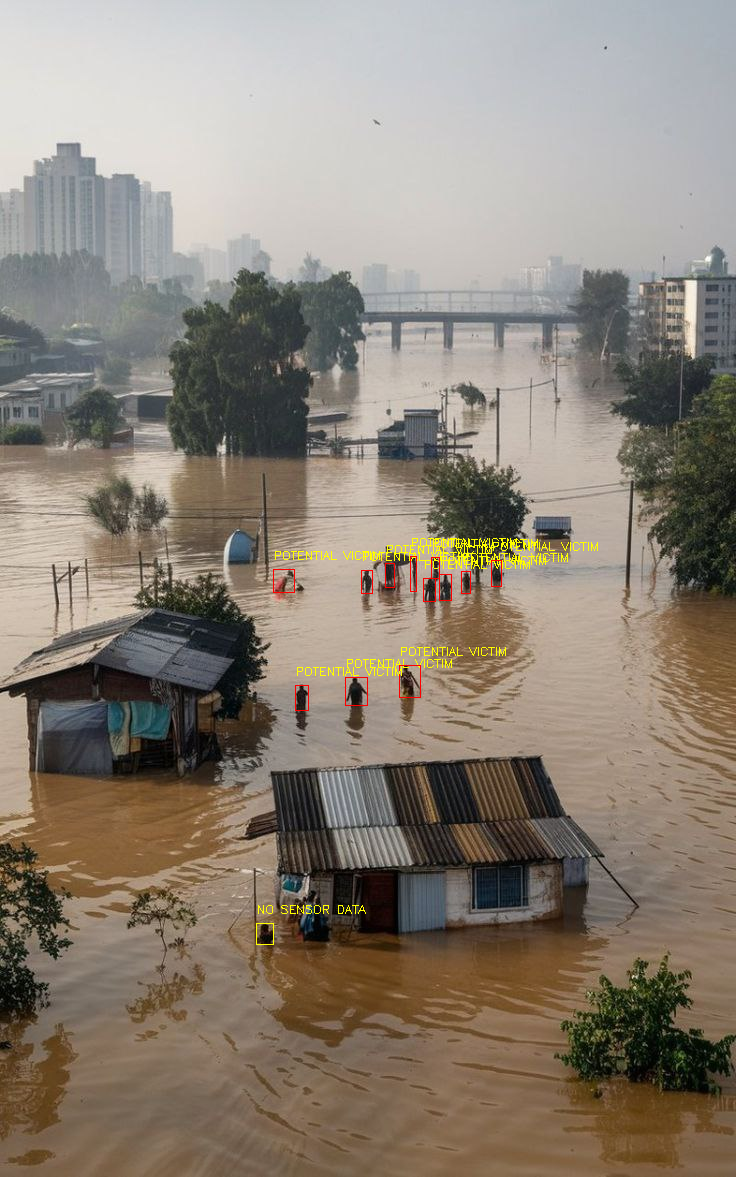

In [38]:
import cv2
import pandas as pd
import joblib
import os
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

print("1. Loading Ensemble Systems...")
# Load the ENSEMBLE model and the CSV
ensemble_model = joblib.load('ensemble_sensor_model.pkl')
sensor_data = pd.read_csv('modified_fused_sensor_data.csv')

# Load YOLO
print("-> Loading YOLO AI...")
yolo_model = YOLO('yolov8l.pt') # Downloads the large model automatically

# >>> IMPORTANT: Change this to the exact name of your uploaded image <<<
image_name = 'photo_2026-04-03_17-13-00.jpg' 

if not os.path.exists(image_name):
    print(f"ERROR: Image '{image_name}' not found. Did you upload it in Step 2?")
else:
    image = cv2.imread(image_name)
    
    # Run YOLO detection
    print("\n2. Scanning image for humans with YOLO...")
    results = yolo_model(image, classes=[0], conf=0.15, imgsz=1280)
    boxes = results[0].boxes
    
    print(f"Raw YOLO detections: {len(boxes)}")

    if len(boxes) > 0:
        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            confidence = float(box.conf[0]) * 100
            x, y, w, h = int(x1), int(y1), int(x2 - x1), int(y2 - y1)

            print(f"\nYOLO found shape at X:{x}, Y:{y}. Asking Ensemble for verification...")

            # Filter sensor data within the YOLO bounding box
            box_data = sensor_data[
                (sensor_data['Pixel_X'] >= x) & (sensor_data['Pixel_X'] <= x + w) &
                (sensor_data['Pixel_Y'] >= y) & (sensor_data['Pixel_Y'] <= y + h)
            ]

            if not box_data.empty:
                # Note: We now include Temperature_C as it was critical in the modified dataset
                features = box_data[['Pixel_X', 'Pixel_Y', 'Depth_mm', 'Temperature_C', 'ToF_Amplitude']]
                
                # The Ensemble predicts
                predictions = ensemble_model.predict(features)
                human_pixel_count = (predictions == 'Victim').sum()
                
                print(f"Ensemble sensor check: {human_pixel_count} pixels verified.")

                if human_pixel_count>0: #* Confirmed by both YOLO and the Ensemble
                
                    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 0, 255), 2)
                    cv2.putText(image, f"VERIFIED VICTIM {confidence:.1f}%", (x, y - 10), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)
                elif human_pixel_count==0: #* Rechecking is needed coz only one model identified the victims(YOLOV8) not by ensemble learning model
                   
                    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 0, 255), 1)
                    cv2.putText(image, "POTENTIAL VICTIM", (x, y - 10), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 255), 1)
            else:
                print("No sensor data found in this exact pixel region.")
                cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 255), 1)
                cv2.putText(image, "NO SENSOR DATA", (x, y - 10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 255), 1)

    # Display final annotated image
    cv2_imshow(image)